In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from typing import cast
import os
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
cfg_dummy = hfn.TrainConfig(config_name="p1_dummy_cfg", part1=True)

{
  "config_name": "p1_dummy_cfg",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2019-11-06 18:40:00",
  "test_end_time": "2020-04-01 04:00:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator

In [3]:
files = glob(os.path.join(ic.PATH_IMPUTED, "*csv"))

df_list = []
for f in files:
    df_list.append(pd.read_csv(f))

df_total = pd.concat(df_list, ignore_index=True)

In [4]:
mask = df_total[ic.TS_COL].between(ic.TRAIN_START , ic.TRAIN_END, inclusive="both")
df_train = df_total[mask]

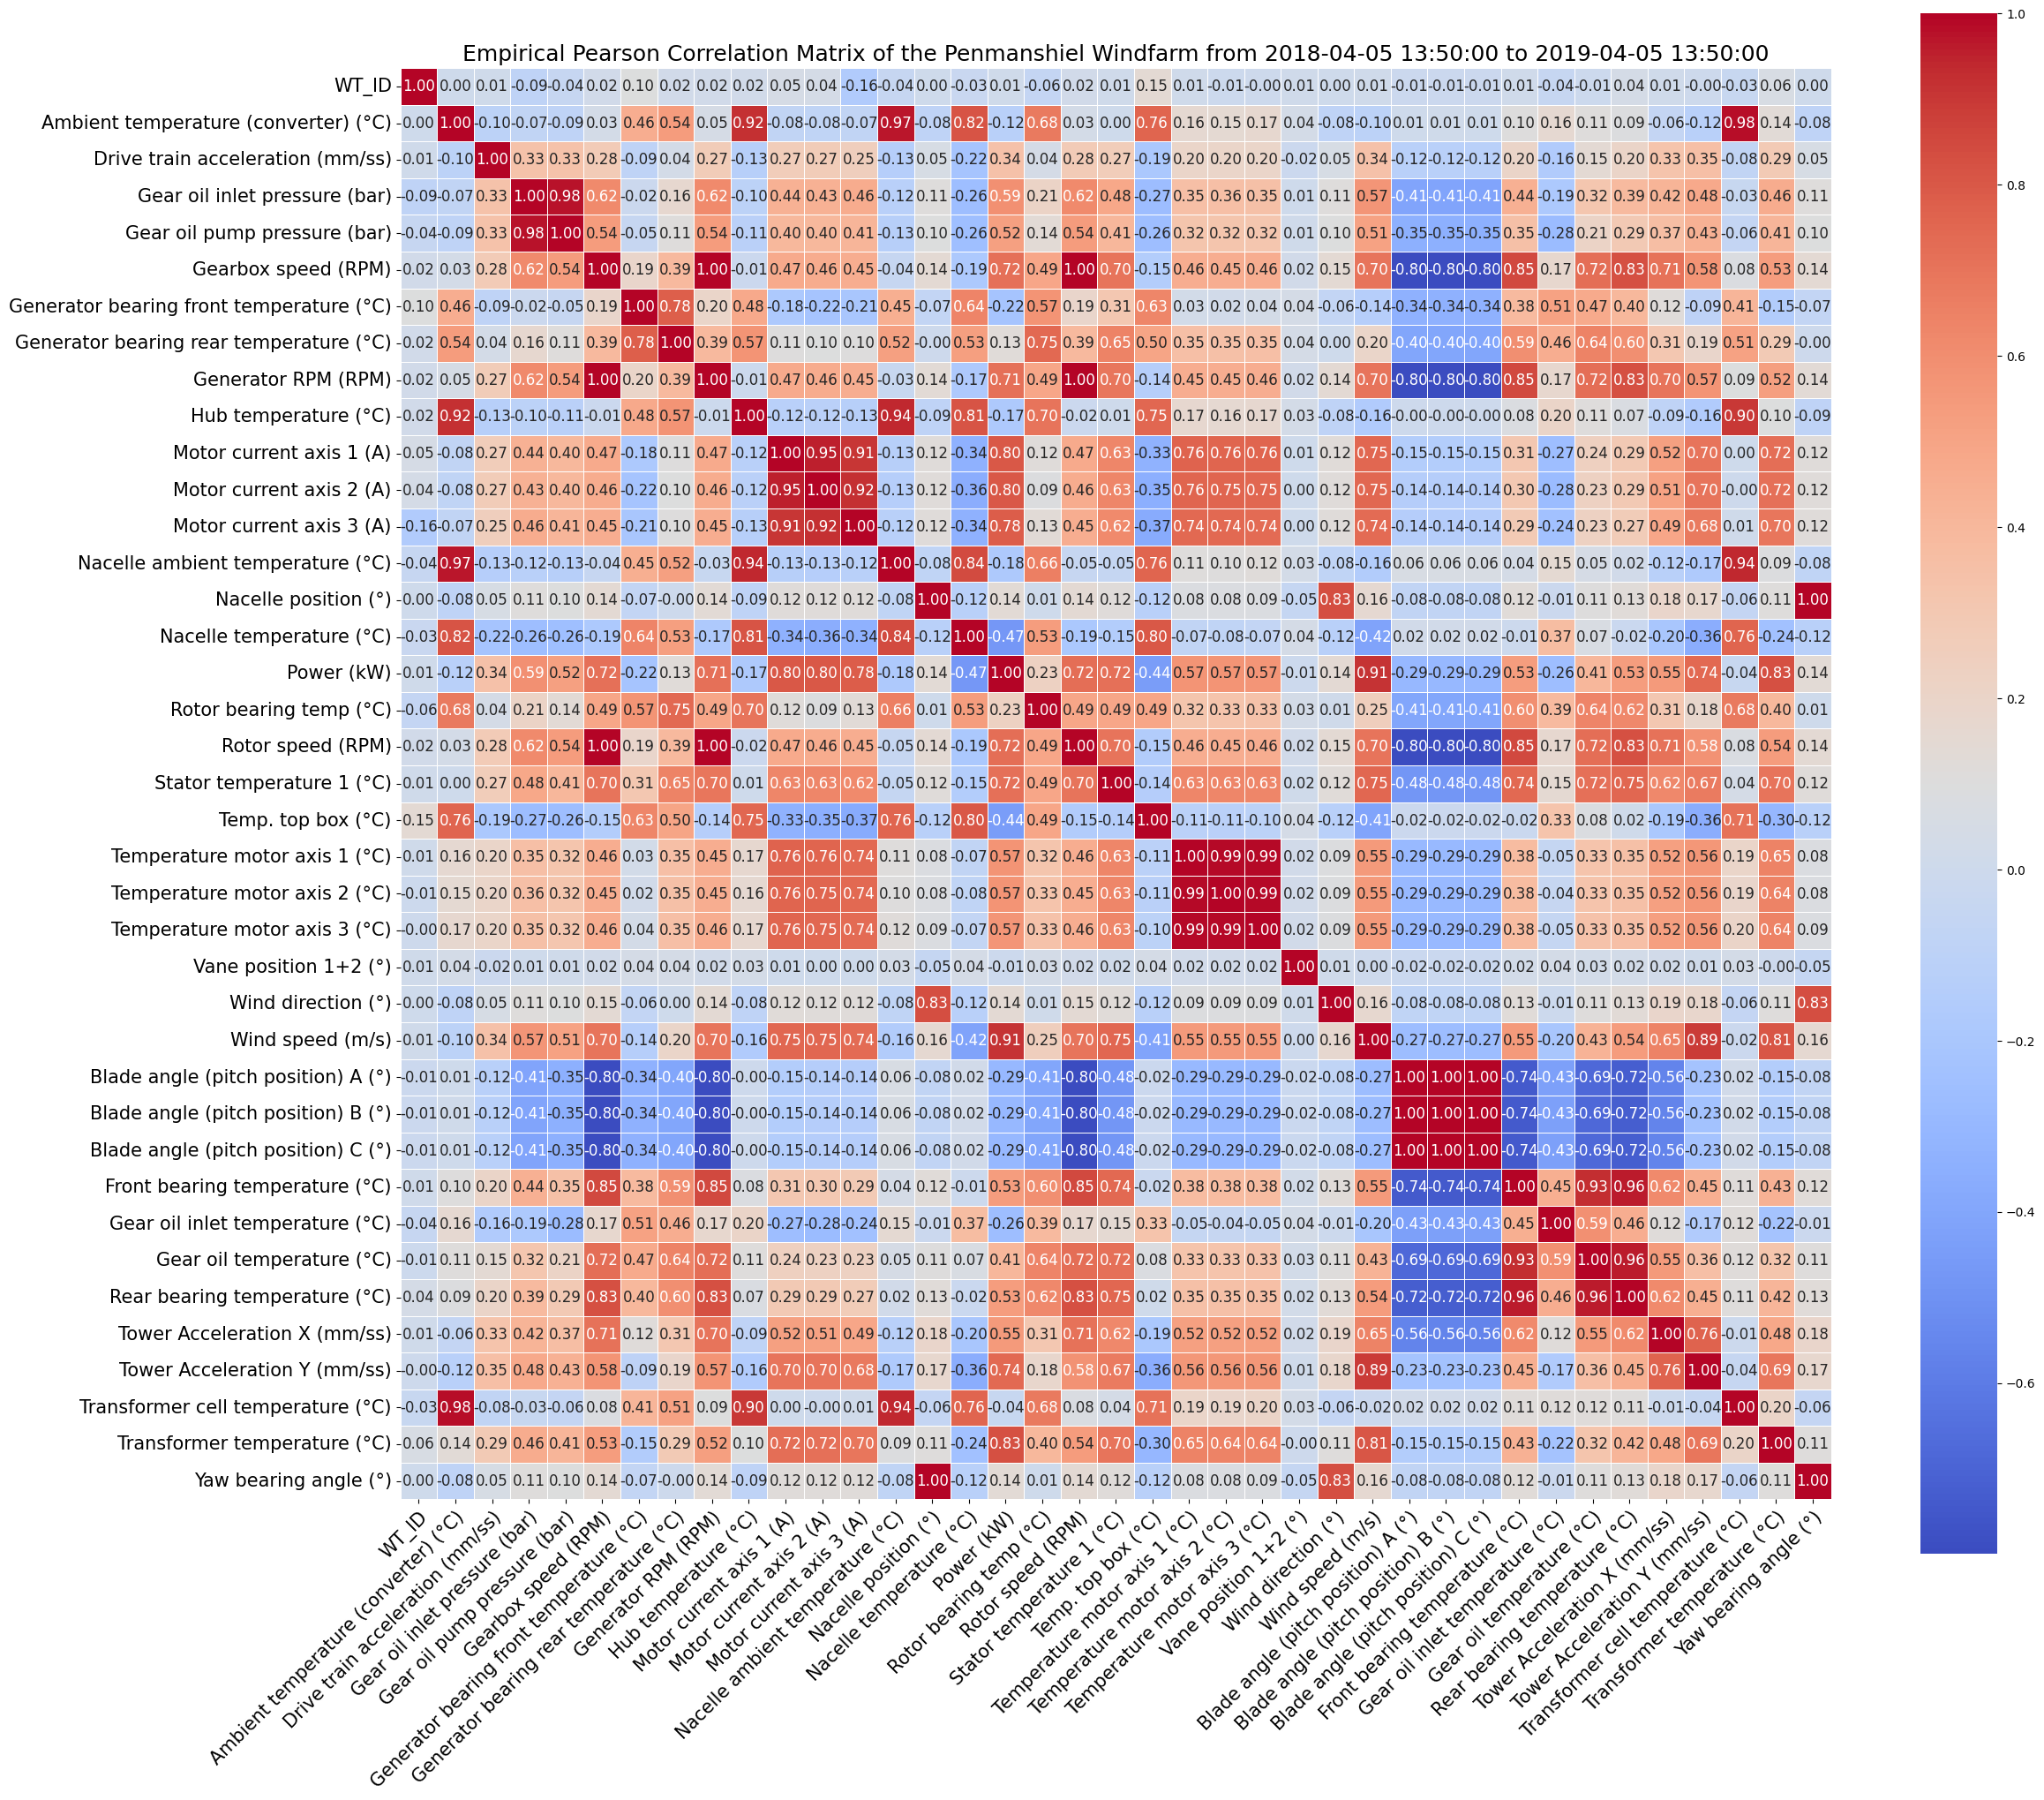

In [5]:
numerical_subset = df_train.select_dtypes(include=["float", "int"])

correlation_matrix = numerical_subset.corr()

plt.figure(figsize=(25, 25))
ax = sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.75},
    linewidths=0.5,
    annot_kws={"size": 12}
)
plt.title(f"Empirical Pearson Correlation Matrix of the Penmanshiel Windfarm from {ic.TRAIN_START} to {ic.TRAIN_END}", fontsize=18)

ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=15)

#plt.xticks(rotation=45)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

In [9]:
display(numerical_subset)

,WT_ID,Ambient temperature (converter) (°C),Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),...,Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
93143,10,9.325000,83.771255,73.893341,278.424957,1367.796143,38.070000,38.689999,1367.280396,13.000,...,0.000000,63.134998,41.215000,53.450001,58.599998,95.407021,24.838570,11.405000,37.424999,263.073761
93144,10,9.421667,74.655060,73.764961,277.703827,1315.326660,38.788334,39.311665,1314.831421,13.000,...,0.280657,63.448334,41.511665,53.576668,58.849998,80.319031,24.520512,11.480000,37.391666,255.862030
93145,10,9.678333,80.697540,72.869965,275.970703,1491.923584,39.888332,40.183334,1491.143188,13.000,...,0.131996,62.490002,41.985001,53.533333,58.256668,70.224258,26.170935,11.746667,37.276665,253.195679
93146,10,9.548333,89.827606,66.711533,253.797516,1482.711548,39.688332,40.148335,1482.276367,13.000,...,0.000000,66.991669,45.573334,54.783333,62.139999,70.493835,23.590015,11.220000,37.953335,253.195679
93147,10,9.566667,89.401253,65.972282,257.082275,1405.899658,38.044998,38.619999,1405.585571,13.000,...,0.049332,66.074997,47.993332,54.881668,61.341667,72.243156,27.721466,11.208333,38.056667,253.195679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4603023,9,13.475000,11.841444,61.644720,242.517944,1800.269737,39.376666,38.215000,1796.182190,15.686,...,0.823291,72.668333,46.628334,58.405000,66.716667,73.299566,36.416564,14.705000,54.750000,113.878822
4603024,9,13.253333,14.282942,113.758451,463.731340,1796.387024,38.506667,38.215001,1792.472778,16.000,...,1.122040,73.550000,28.971667,58.583333,67.465000,66.862010,38.428261,14.711667,56.763334,113.878822
4603025,9,13.325000,13.519807,133.081458,517.857630,1790.464314,37.471666,38.105000,1786.802769,16.000,...,0.800605,69.611667,22.230000,56.940000,65.523335,58.504986,33.361034,14.560000,58.540000,113.647750
4603026,9,13.083333,11.748608,135.120573,522.034025,1790.338696,36.618334,37.970000,1786.593334,16.000,...,0.998239,68.066666,21.758333,56.323333,64.996665,69.978110,34.655094,14.530000,60.060000,108.153095


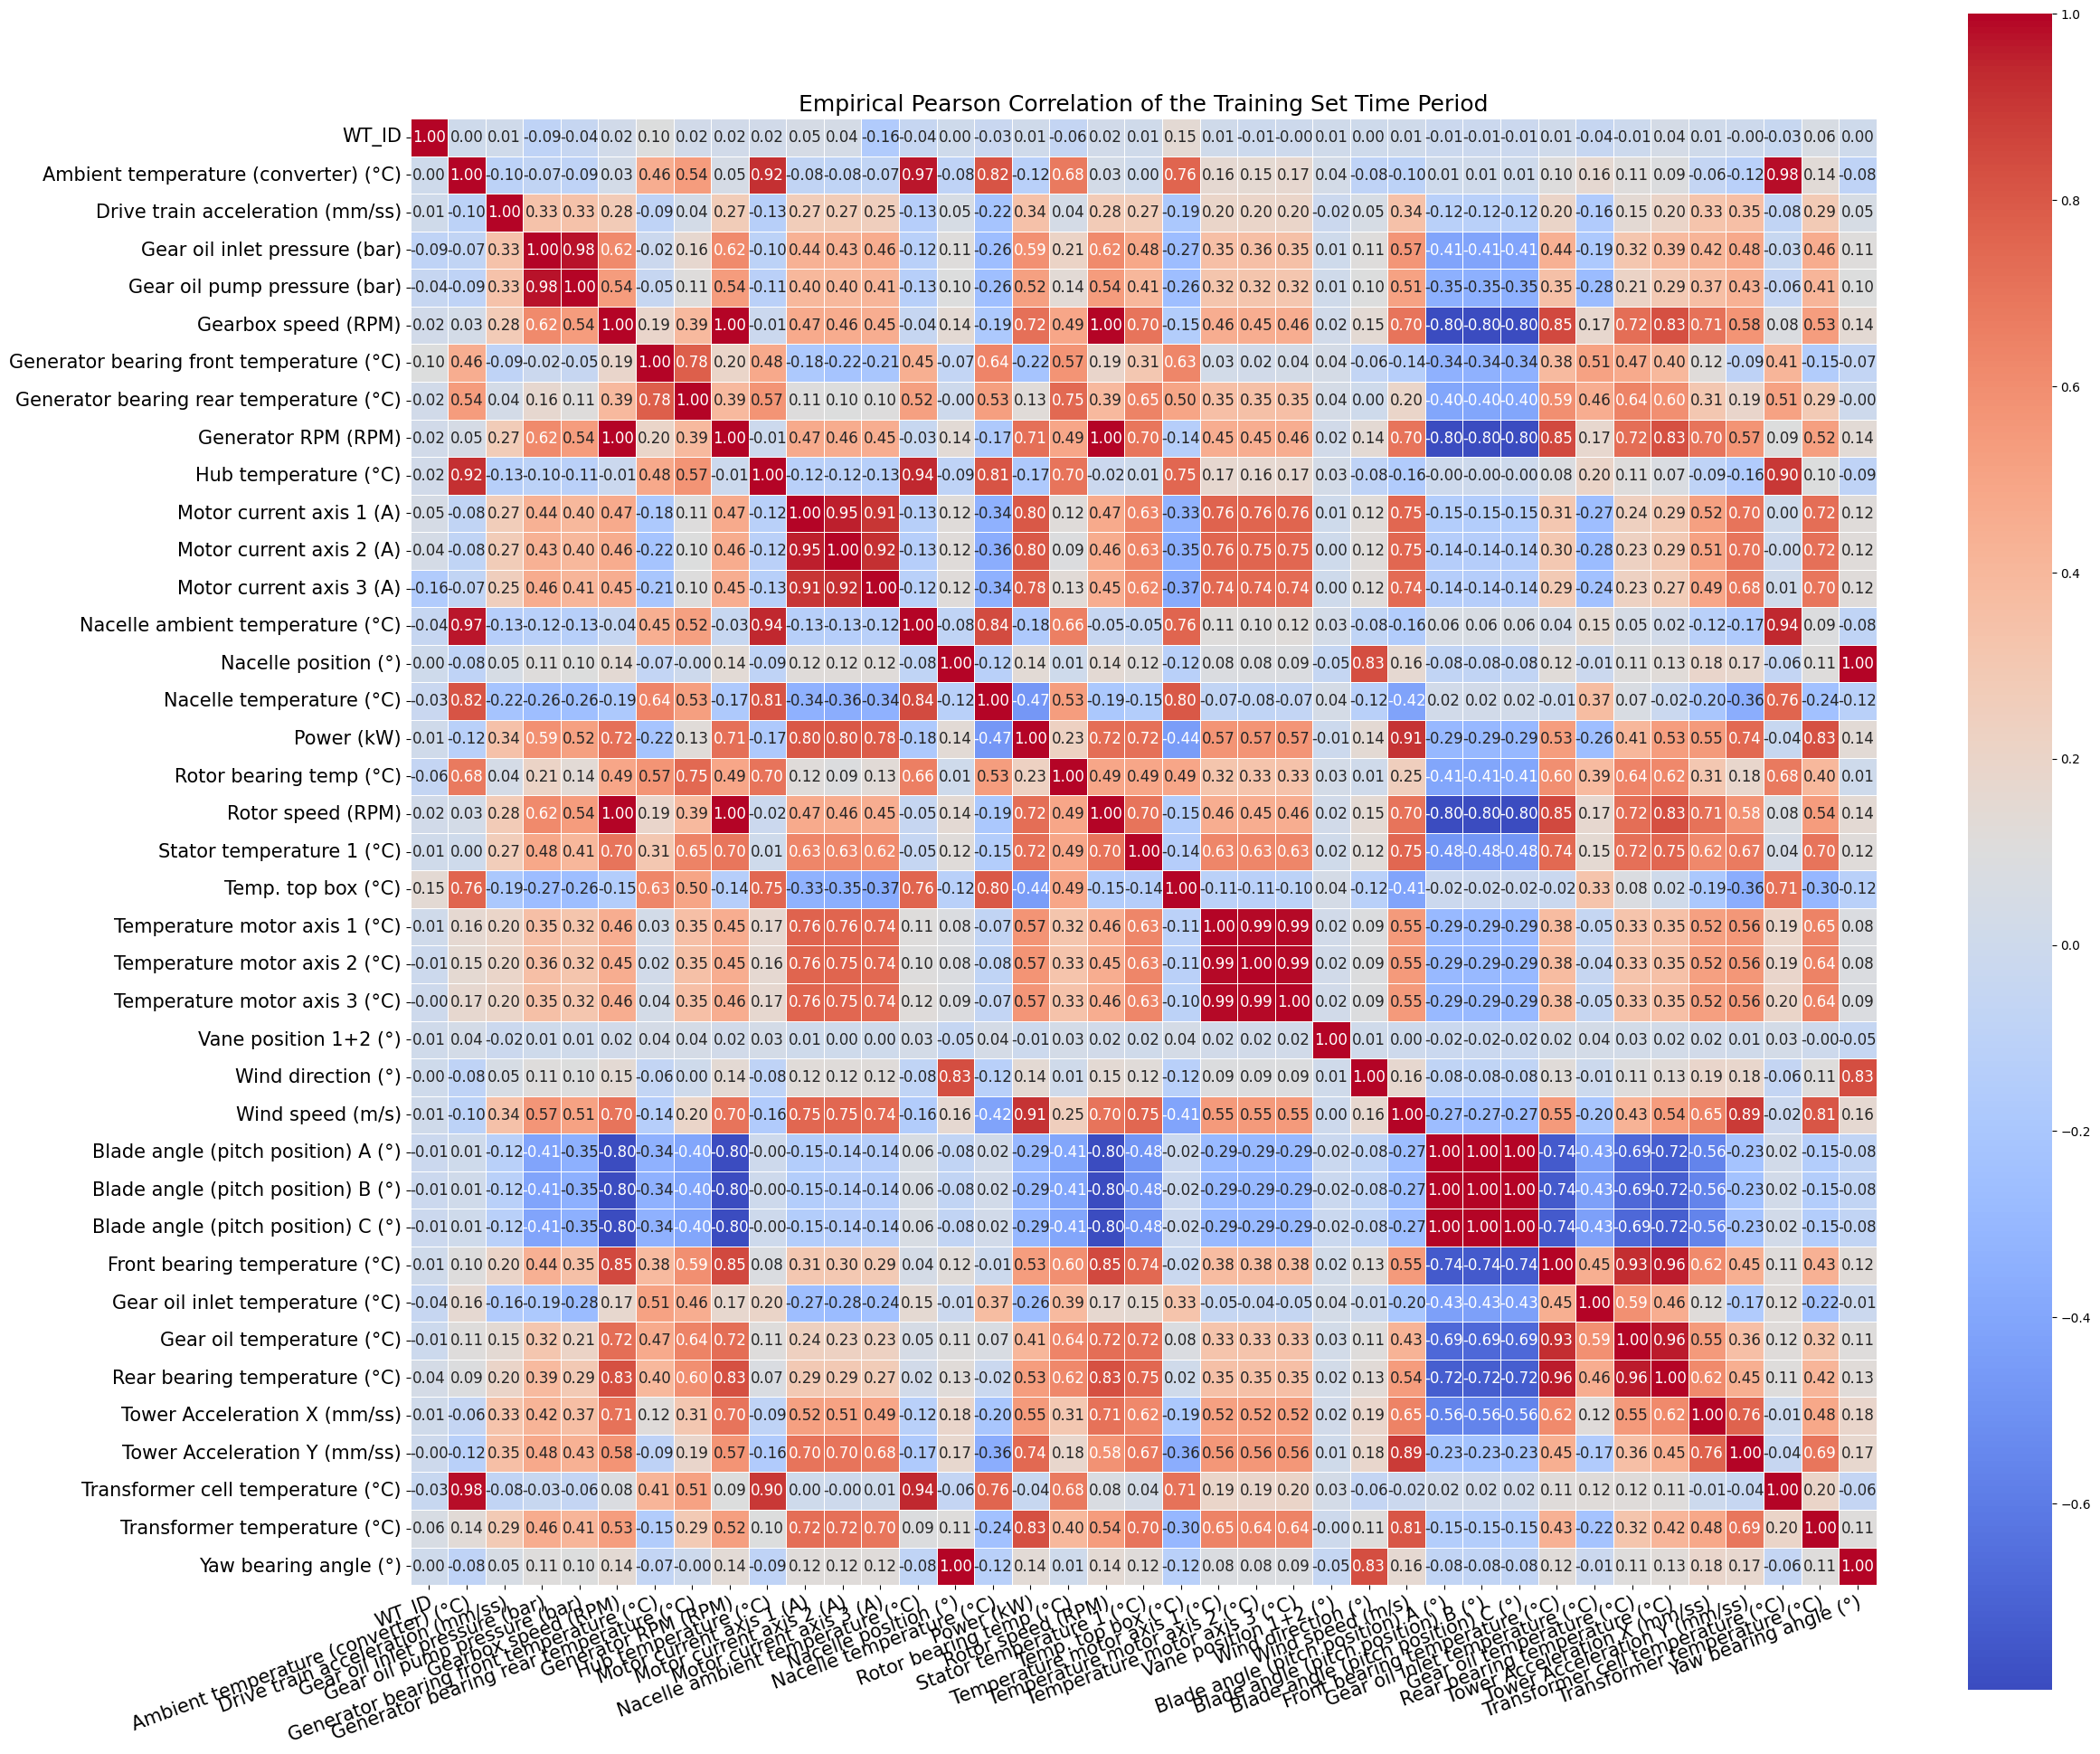

In [ ]:
sigs = list(numerical_subset.columns)
pp.plot_corr_matrix(sigs,
                    numerical_subset,
                    filename="large_corr_matrix.png",
                    cbar_kws={"shrink": 0.75},
                    figsize=(25,25),
                    x_label_rotation=45)

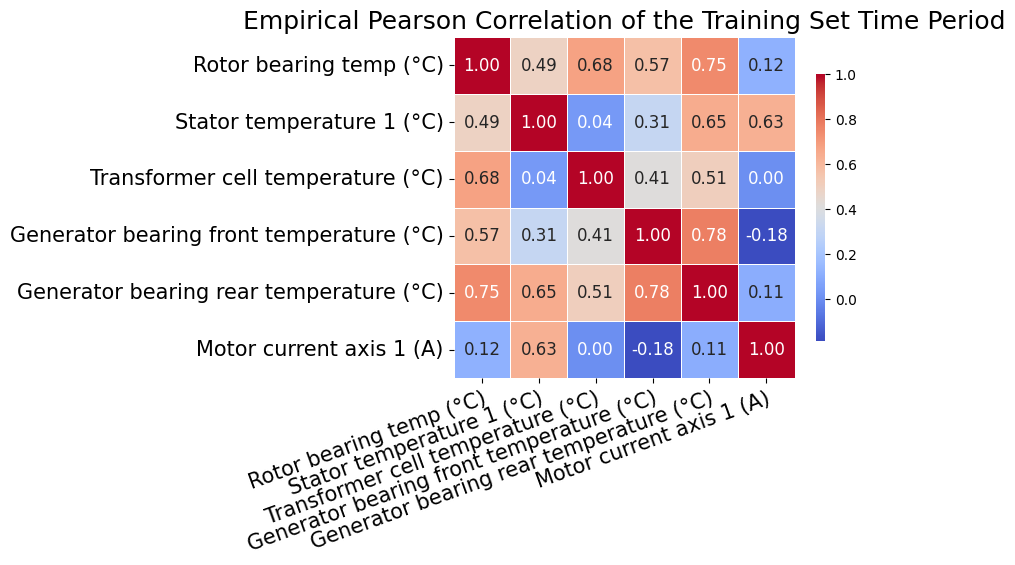

In [7]:
sigs = ["Rotor bearing temp (°C)",
"Stator temperature 1 (°C)",
"Transformer cell temperature (°C)",
"Generator bearing front temperature (°C)",
"Generator bearing rear temperature (°C)",
"Motor current axis 1 (A)",]

pp.plot_corr_matrix(sigs, 
                    df_train)